<a href="https://colab.research.google.com/github/Navitapnchr/analisis-sentimen-imdb/blob/main/Analisis_Sentimen_IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv('/content/IMDB Dataset.csv')

print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df = df.sample(n=3000, random_state=42)

print(df.shape)

(3000, 2)


In [ ]:
print(df['sentiment'].value_counts())

sentiment
positive    1509
negative    1491
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

In [ ]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

print(X.shape)

(3000, 3000)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy :", acc)

Accuracy : 0.8383333333333334


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.82      0.85      0.84       292
    positive       0.85      0.83      0.84       308

    accuracy                           0.84       600
   macro avg       0.84      0.84      0.84       600
weighted avg       0.84      0.84      0.84       600



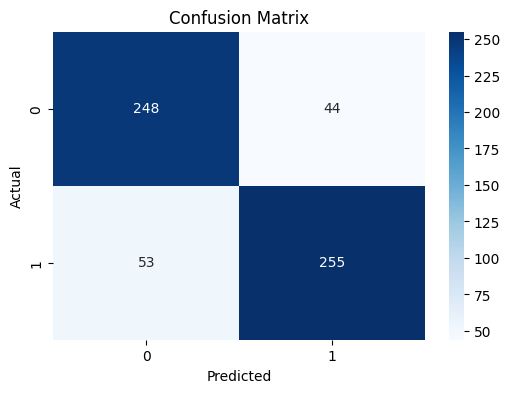

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

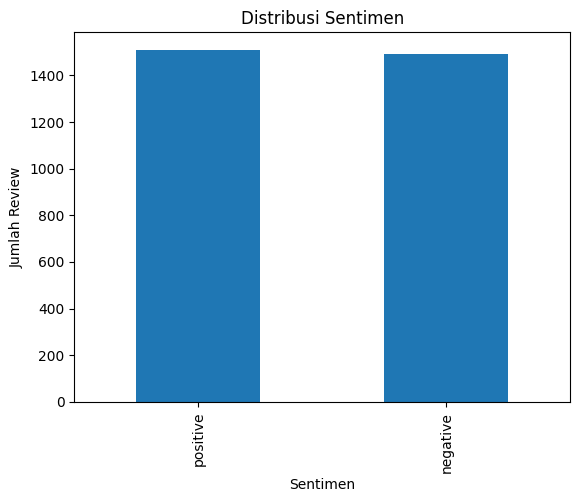

In [ ]:
df['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Review')

plt.show()

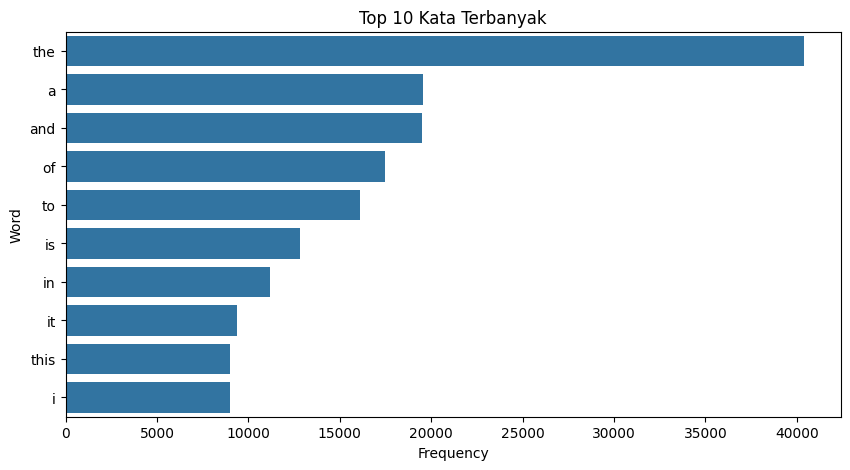

In [ ]:
from collections import Counter

all_words = " ".join(df['clean_review'])

words = all_words.split()

word_freq = Counter(words)

top_words = word_freq.most_common(10)

word_df = pd.DataFrame(
    top_words,
    columns=['Word','Frequency']
)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Frequency',
    y='Word',
    data=word_df
)

plt.title('Top 10 Kata Terbanyak')
plt.show()

In [ ]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return ' '.join(words)

df['clean_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
df['clean_review']

,clean_review
33553,really liked summerslam due look arena curtain...
9427,many television shows appeal quite many differ...
199,film quickly gets major chase scene ever incre...
12447,jane austen would definitely approve onebr br ...
39489,expectations somewhat high went see movie thou...
...,...
2874,terror aisles might look like ultimate treat h...
45435,steamboat willy first cartoon feature mickey m...
22603,absolutely nothing happens sloooow annoying th...
37027,unpolitically correct guy say sexist really me...


In [ ]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.8383333333333334


In [ ]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)

print(acc)

0.845


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.83      0.86      0.84       292
    positive       0.86      0.83      0.85       308

    accuracy                           0.84       600
   macro avg       0.85      0.85      0.84       600
weighted avg       0.85      0.84      0.85       600



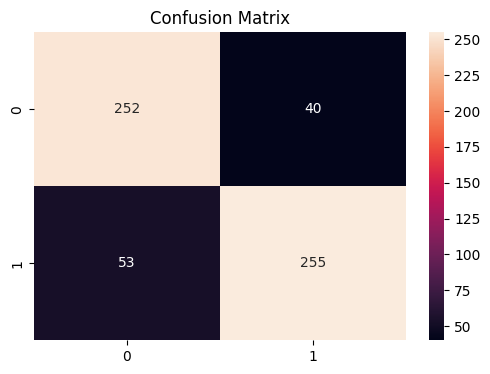

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.show()

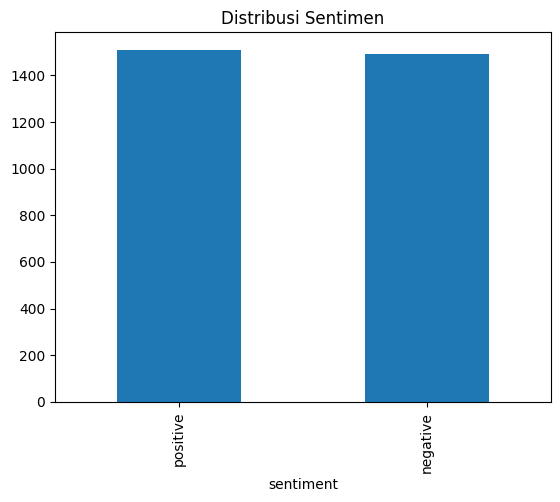

In [ ]:
df['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title('Distribusi Sentimen')
plt.show()

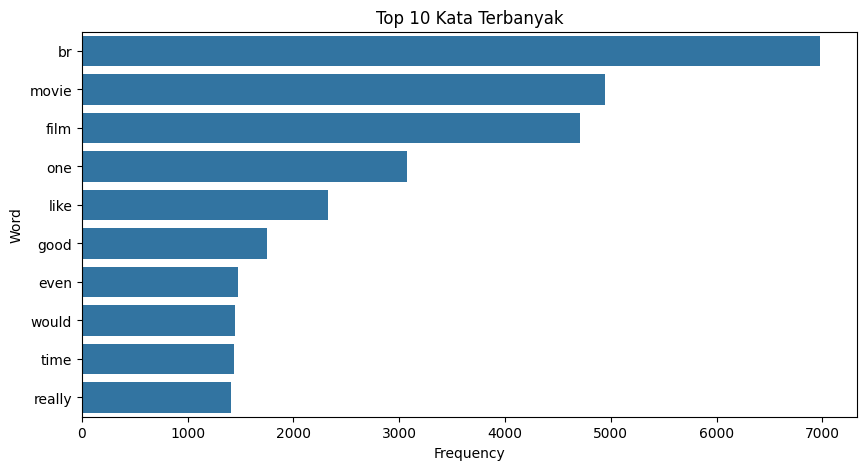

In [ ]:
from collections import Counter

all_words = " ".join(df['clean_review'])

words = all_words.split()

word_freq = Counter(words)

top_words = word_freq.most_common(10)

word_df = pd.DataFrame(
    top_words,
    columns=['Word','Frequency']
)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Frequency',
    y='Word',
    data=word_df
)

plt.title('Top 10 Kata Terbanyak')
plt.show()

In [ ]:
def clean_text(text):
    text = text.lower()

    # hapus tag HTML <br />
    text = re.sub(r'<br\s*/?>', ' ', text)

    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return ' '.join(words)

In [ ]:
df['clean_review'] = df['review'].apply(clean_text)

In [ ]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.85


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.84      0.86      0.85       292
    positive       0.86      0.84      0.85       308

    accuracy                           0.85       600
   macro avg       0.85      0.85      0.85       600
weighted avg       0.85      0.85      0.85       600



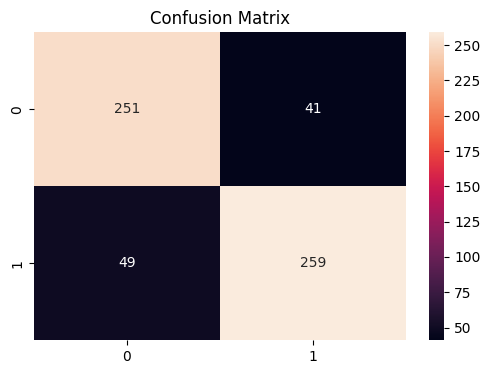

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.show()

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(acc)

0.85


In [ ]:
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()

    # hapus semua tag html
    text = re.sub(r'<.*?>', ' ', text)

    # sisakan huruf saja
    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return ' '.join(words)

df['clean_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NameError: name 'df' is not defined

In [ ]:
import pandas as pd

df = pd.read_csv(...)

ValueError: Invalid file path or buffer object type: <class 'ellipsis'>

In [ ]:
import pandas as pd

df = pd.read_csv('IMDB Dataset.csv')

print(df.shape)

(50000, 2)


In [ ]:
df['clean_review'] = df['review'].apply(clean_text)

In [ ]:
df = df.sample(n=3000, random_state=42)

print(df.shape)

(3000, 3)


In [ ]:
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()

    # hapus semua tag html
    text = re.sub(r'<.*?>', ' ', text)

    # sisakan huruf
    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return ' '.join(words)

df['clean_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
all_words = " ".join(df['clean_review'])

print(" br " in all_words)

True


In [ ]:
word_list = all_words.split()

print('br' in word_list)

True


In [ ]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r'<.*?>', ' ', text)

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    words = [w for w in words if w != 'br']

    return ' '.join(words)

In [ ]:
df['clean_review'] = df['review'].apply(clean_text)

all_words = " ".join(df['clean_review'])

print(" br " in all_words)

False


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

print(X.shape)

(3000, 3000)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

print(acc)

0.8483333333333334


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.84      0.86      0.85       292
    positive       0.86      0.84      0.85       308

    accuracy                           0.85       600
   macro avg       0.85      0.85      0.85       600
weighted avg       0.85      0.85      0.85       600



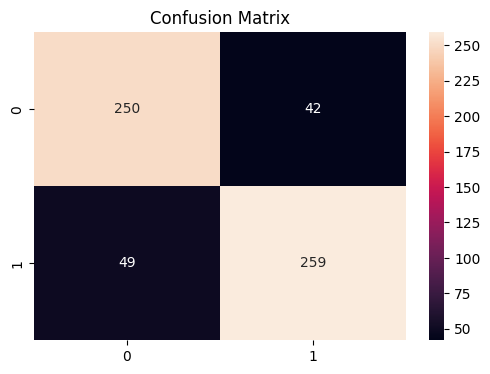

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.show()

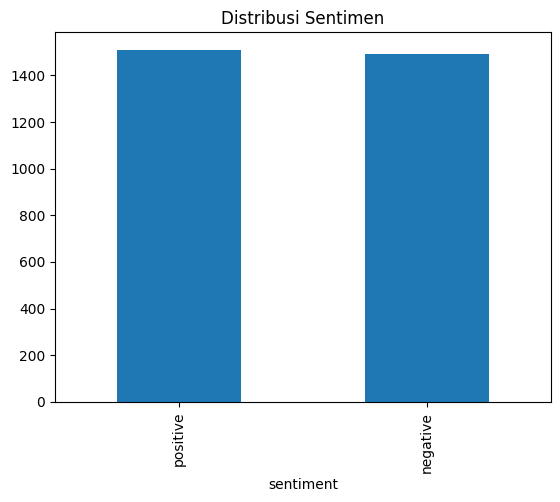

In [ ]:
df['sentiment'].value_counts().plot(kind='bar')

plt.title('Distribusi Sentimen')
plt.show()

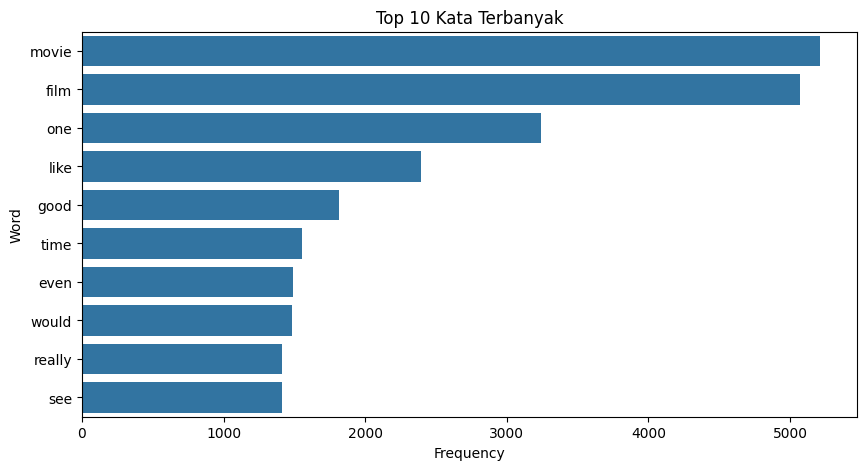

In [ ]:
from collections import Counter

all_words = " ".join(df['clean_review'])

words = all_words.split()

word_freq = Counter(words)

top_words = word_freq.most_common(10)

word_df = pd.DataFrame(
    top_words,
    columns=['Word','Frequency']
)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Frequency',
    y='Word',
    data=word_df
)

plt.title('Top 10 Kata Terbanyak')
plt.show()